# 03 — Descriptive Statistics for Revenue & Conversion

This notebook computes comprehensive descriptive statistics on the cleaned
e-commerce session-level dataset (`fact_sessions_clean.csv`).

**Variables analysed:**
| Column | Type | Description |
|---|---|---|
| `price_usd` | Continuous | Order revenue (0 for non-converted sessions) |
| `net_revenue_usd` | Continuous | Revenue after refunds |
| `is_converted` | Binary (0/1) | Whether the session resulted in an order |

**Metrics computed:** mean, median, mode, std, variance, min/max, range,
quartiles, IQR, skewness, kurtosis, and proportion statistics for the binary
variable.

## 1 · Setup and Library Imports

In [1]:
# ── imports ──────────────────────────────────────────────────────────────────
import sys, os
import pandas as pd
import numpy as np
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
import seaborn as sns

# add project root so we can import scripts/
sys.path.insert(0, os.path.abspath(".."))
from scripts.stats_utils import compute_descriptive_stats, compute_binary_stats, build_stats_table

# ── configuration ────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.float_format", "{:.4f}".format)

# ── paths ────────────────────────────────────────────────────────────────────
INPUT_PATH = "../data/processed/fact_sessions_clean.csv"
DOCS_PATH  = "../docs/"

## 2 · Load and Preview the Cleaned Dataset

In [2]:
# ── load data ────────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_PATH)
df["date"] = pd.to_datetime(df["date"])

# quick sanity checks
TARGET_COLS = ["price_usd", "net_revenue_usd", "is_converted"]
print(f"Shape : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nTarget columns – non-null counts:")
print(df[TARGET_COLS].notnull().sum())
df[TARGET_COLS].head(10)

Shape : (472871, 19)
Date range : 2012-03-19 → 2015-03-19

Target columns – non-null counts:
price_usd          472871
net_revenue_usd    472871
is_converted       472871
dtype: int64


,price_usd,net_revenue_usd,is_converted
0,0.0000,0.0000,0
1,0.0000,0.0000,0
2,0.0000,0.0000,0
3,0.0000,0.0000,0
4,0.0000,0.0000,0
5,0.0000,0.0000,0
6,0.0000,0.0000,0
7,0.0000,0.0000,0
8,0.0000,0.0000,0
9,0.0000,0.0000,0


## 3 · Reusable Descriptive Statistics Functions

The helper functions live in **`scripts/stats_utils.py`** and are imported above.
Below is a quick reference of each function:

| Function | Purpose |
|---|---|
| `compute_descriptive_stats(df, col)` | Returns a `pd.Series` with 14 statistics for a continuous column |
| `compute_binary_stats(df, col)` | Returns proportion ($\hat{p}$), variance $p(1-p)$, and counts for a binary column |
| `build_stats_table(df, cols)` | Aggregates `compute_descriptive_stats` across several columns into one DataFrame |

## 4 · Descriptive Statistics for Continuous Variables

We compute the following for `price_usd` and `net_revenue_usd`:

| Statistic | Formula / Purpose |
|---|---|
| Mean | $\bar{x} = \frac{1}{n}\sum x_i$ — central tendency |
| Median | Middle value — robust to outliers |
| Mode | Most frequent value |
| Std Dev | $s = \sqrt{\frac{1}{n-1}\sum (x_i - \bar{x})^2}$ — absolute volatility |
| Variance | $s^2$ — squared volatility |
| Min / Max | Range extremes |
| Range | $\max - \min$ |
| Q1, Q2, Q3 | 25th, 50th, 75th percentiles |
| IQR | $Q3 - Q1$ — middle 50 % spread |
| Skewness | $g_1 = \frac{m_3}{m_2^{3/2}}$ — asymmetry |
| Kurtosis | $g_2 = \frac{m_4}{m_2^{2}}$ — tail heaviness (excess, so normal = 0) |

In [3]:
# ── compute stats for continuous columns ─────────────────────────────────────
continuous_cols = ["price_usd", "net_revenue_usd"]

stats_table = build_stats_table(df, continuous_cols)
stats_table

,price_usd,net_revenue_usd
Mean,4.0994,3.9190
Median,0.0000,0.0000
Mode,0.0000,0.0000
Std Dev,15.8366,15.4413
Variance,250.7991,238.4339
Min,0.0000,0.0000
Max,109.9800,109.9800
Range,109.9800,109.9800
Q1 (25%),0.0000,0.0000
Q2 (50%),0.0000,0.0000


## 5 · Proportion Statistics for Binary Variable (`is_converted`)

For a Bernoulli random variable $X \in \{0, 1\}$:

$$\hat{p} = \bar{X}, \qquad \text{Var}(X) = p(1-p)$$

The mean directly represents the **conversion rate**.

In [4]:
# ── binary stats for is_converted ────────────────────────────────────────────
binary_stats = compute_binary_stats(df, "is_converted")
print(binary_stats.to_frame("is_converted").to_string())

                  is_converted
Count              472871.0000
Sum (1s)            32313.0000
Proportion (p)          0.0683
Variance p*(1-p)        0.0637


## 6 · Consolidated Summary Table

In [5]:
# ── merge continuous + binary stats into one table ───────────────────────────
summary = stats_table.copy()

# add is_converted column with NaN for inapplicable rows, fill proportion & variance
summary["is_converted"] = np.nan
summary.loc["Mean", "is_converted"]     = binary_stats["Proportion (p)"]
summary.loc["Variance", "is_converted"] = binary_stats["Variance p*(1-p)"]

summary.style.format("{:.4f}", na_rep="—")

,price_usd,net_revenue_usd,is_converted
Mean,4.0994,3.9190,0.0683
Median,0.0000,0.0000,—
Mode,0.0000,0.0000,—
Std Dev,15.8366,15.4413,—
Variance,250.7991,238.4339,0.0637
Min,0.0000,0.0000,—
Max,109.9800,109.9800,—
Range,109.9800,109.9800,—
Q1 (25%),0.0000,0.0000,—
Q2 (50%),0.0000,0.0000,—


## 7 · Visualise Distributions — Histograms with KDE

Histograms overlaid with a KDE curve reveal the shape of each distribution.
Vertical lines mark the **mean** (red) and **median** (green) to highlight skew.

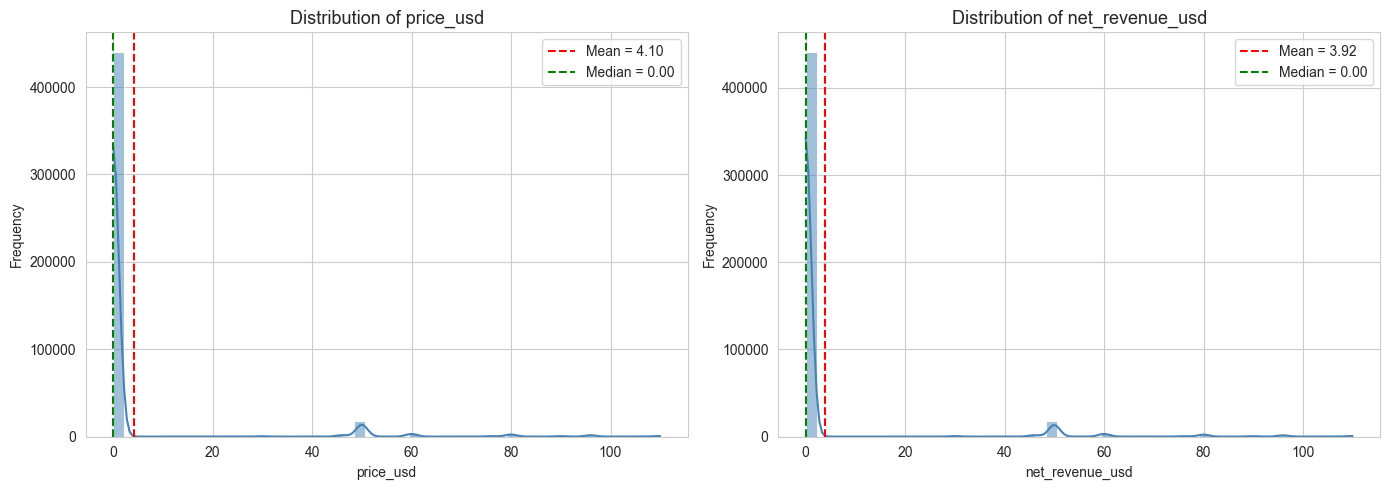

In [ ]:
# -- histogram + KDE for continuous variables --------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, continuous_cols):
    data = df[col].dropna()
    sns.histplot(x=data.to_numpy(), kde=True, bins=50, ax=ax, color="steelblue", edgecolor="white")  # pyright: ignore[reportArgumentType]
    ax.axvline(data.mean(),   color="red",   linestyle="--", linewidth=1.5, label=f"Mean = {data.mean():.2f}")
    ax.axvline(data.median(), color="green", linestyle="--", linewidth=1.5, label=f"Median = {data.median():.2f}")
    ax.set_title(f"Distribution of {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, "distribution_continuous.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8 · Visualise Spread and Outliers — Boxplots

Boxplots show the IQR (box), median (line inside box), and outliers (points
beyond the whiskers at $Q1 - 1.5 \cdot IQR$ and $Q3 + 1.5 \cdot IQR$).

A second row filters to **converted sessions only** (`is_converted == 1`) to
reveal the revenue distribution among buyers.

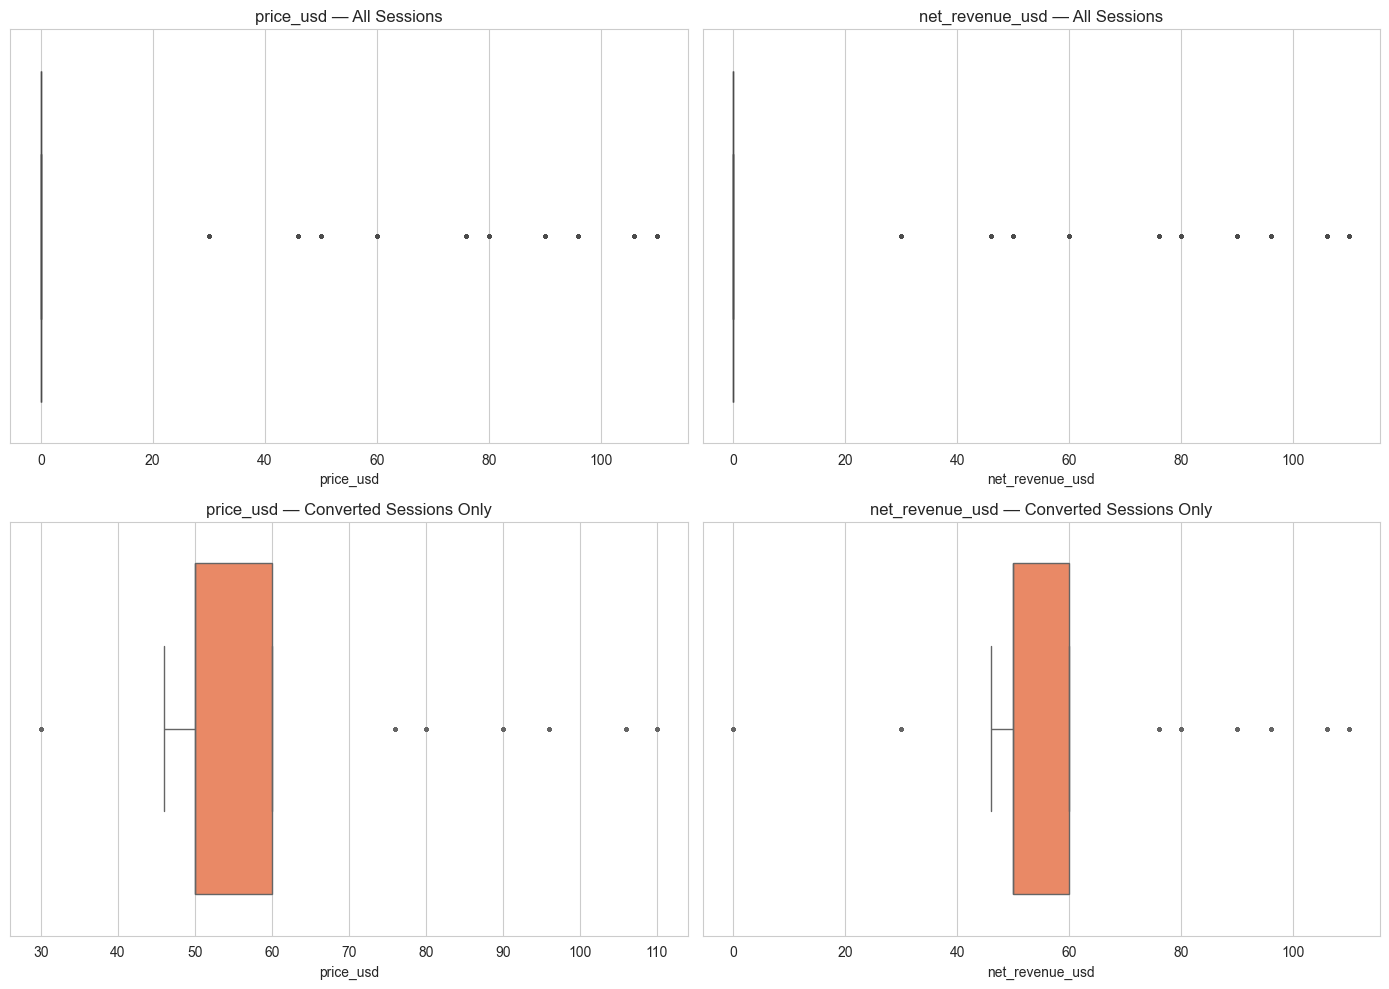

In [7]:
# ── boxplots: all sessions vs converted-only ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for j, col in enumerate(continuous_cols):
    # row 0 — all sessions
    sns.boxplot(x=df[col], ax=axes[0, j], color="steelblue", fliersize=2)
    axes[0, j].set_title(f"{col} — All Sessions", fontsize=12)
    axes[0, j].set_xlabel(col)

    # row 1 — converted sessions only
    converted = df.loc[df["is_converted"] == 1, col]
    sns.boxplot(x=converted, ax=axes[1, j], color="coral", fliersize=2)
    axes[1, j].set_title(f"{col} — Converted Sessions Only", fontsize=12)
    axes[1, j].set_xlabel(col)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, "boxplot_revenue.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9 · Interpretation — Normality, Outliers, and Metric Selection

In [8]:
# ── outlier detection using 1.5 × IQR rule ───────────────────────────────────
print("Outlier counts (1.5 × IQR rule)\n" + "=" * 45)

for col in continuous_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = s[(s < lower_fence) | (s > upper_fence)]
    print(f"\n{col}:")
    print(f"  Fences       : [{lower_fence:.2f}, {upper_fence:.2f}]")
    print(f"  # outliers   : {len(outliers)} ({len(outliers)/len(s)*100:.2f}%)")
    print(f"  Skewness     : {s.skew():.4f}")
    print(f"  Kurtosis     : {s.kurtosis():.4f}")

Outlier counts (1.5 × IQR rule)

price_usd:
  Fences       : [0.00, 0.00]
  # outliers   : 32313 (6.83%)
  Skewness     : 4.0332
  Kurtosis     : 16.3158

net_revenue_usd:
  Fences       : [0.00, 0.00]
  # outliers   : 31145 (6.59%)
  Skewness     : 4.1232
  Kurtosis     : 17.1402


### Key Takeaways

**1. Normality**
- If skewness ≠ 0 or excess kurtosis ≠ 0 (Fisher convention), the data is **not normally distributed**.
- Revenue columns are typically **right-skewed** because the majority of sessions have \$0 revenue (non-converted), while a small fraction generates positive revenue.

**2. Outliers**
- The 1.5 × IQR rule flags values below $Q1 - 1.5 \cdot IQR$ or above $Q3 + 1.5 \cdot IQR$.
- Because most sessions are non-converted (revenue = 0), **any converted session with revenue will appear as an outlier** in the all-sessions distribution. This is expected behaviour, not data error.

**3. Mean vs. Median**
- When the distribution is heavily right-skewed, the **median** is a more robust measure of central tendency—it is not pulled by extreme values.
- For revenue, the median is likely \$0 (most sessions don't convert), while the mean reflects an average that includes high-value orders.

**4. Standard Deviation & Business Predictability**
- A large standard deviation relative to the mean signals **high variability** in per-session revenue.
- This is typical for e-commerce: a few high-value sessions drive most revenue, making individual-session revenue hard to predict but aggregate patterns stable at scale.

## 10 · Export Verification & Commit Reminder

In [9]:
# ── verify saved charts ──────────────────────────────────────────────────────
for fname in ["distribution_continuous.png", "boxplot_revenue.png"]:
    path = os.path.join(DOCS_PATH, fname)
    status = "✓ exists" if os.path.exists(path) else "✗ MISSING"
    print(f"  {status}  {path}")

print("\n── Recommended commit ─────────────────────────────────────────────")
print('git commit -m "feat: add descriptive statistics for revenue and conversion'
      ' - mean, median, std, skewness, kurtosis, IQR"')

  ✓ exists  ../docs/distribution_continuous.png
  ✓ exists  ../docs/boxplot_revenue.png

── Recommended commit ─────────────────────────────────────────────
git commit -m "feat: add descriptive statistics for revenue and conversion - mean, median, std, skewness, kurtosis, IQR"
